# D.R.O.N.A. — 05 · Model Evaluation & Comparison

Scores every trained model against its baseline on the four research
contributions, with statistics, error analysis, and a final verdict table.

```
01 data cleaning  ->  02 EDA  ->  03 feature engineering  ->  04 model training  ->  05 evaluation
   & preprocessing                   (dual embeddings)          (Colab A100)          & comparison
```

**Runtime:** CPU is enough for C1-C4; the ChromaDB index from notebook 03 is
rebuilt automatically if missing. **Inputs:** artifacts from 01/03 + checkpoints
from 04 (each section degrades gracefully if a checkpoint is absent).
**Outputs:** `reports/final_comparison.csv`, `reports/evaluation_report.json`,
figures in `reports/figures/05_eval/`.

## Metric selection - and why there is no ROC curve

| Contribution | System | Metrics | Why these |
|---|---|---|---|
| C1 | hybrid retrieval | NDCG@k, MRR, Precision@k, Recall@k | Standard ranked-retrieval metrics; NDCG rewards putting relevant docs *first* |
| C2 | bias detection | per-type Precision/Recall/F1, confusion matrices, error listing | The detector is **rule-based - it outputs decisions, not scores**, so threshold curves (ROC/PR-AUC, calibration) are undefined; honest reporting stops at decision metrics |
| C3 | gesture policies | success rate, mean \|jerk\| (smoothness), path length, apex error + paired stats (Wilcoxon/bootstrap CI, Cohen's d) | Jerk is the standard smoothness measure in motor control; success guards against a policy that is smooth because it barely moves |
| C4 | Nepal grounding | Nepal-tier citation ratio, latency p50/p95 | Directly operationalises the "local-first" claim |
| LLM | base vs LoRA | val cross-entropy (from 04), qualitative side-by-side | Perplexity-style comparison is architecture-fair; generation-quality ablation runs locally with Ollama (`scripts/run_evaluation.py --llm`) |

## 0 · Colab setup

In [1]:
# ===========================================================================
#  D.R.O.N.A. - Colab setup.  *** RUN THIS CELL FIRST ***
#  Target: Google Colab with an A100 GPU (Runtime > Change runtime type).
#  CPU is fine here; a GPU only speeds up the optional embedding rebuild.
# ===========================================================================
import os, sys, subprocess, pathlib

gpu = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout.strip()
print(gpu or "No GPU detected - see the note at the top of this notebook.")

# EDIT this to your GitHub repo URL. Private repo? use a fine-grained read
# token: https://<TOKEN>@github.com/<user>/D.R.O.N.A.git
# Alternatively upload a zip of the project (Colab Files panel) or attach it
# as a Kaggle dataset named 'drona' - the search loop below finds it.
REPO_URL = "https://github.com/trishan9/D.R.O.N.A.git"   # <-- EDIT ME

def _is_repo(p):
    return pathlib.Path(p, "drona", "__init__.py").is_file()

search = [".", "..", "../..", "D.R.O.N.A", "/content/D.R.O.N.A",
          "/kaggle/working/D.R.O.N.A", "/kaggle/input/drona/D.R.O.N.A", "/kaggle/input/drona"]
repo = next((p for p in search if _is_repo(p)), None)
if repo is None:
    dest = "/content/D.R.O.N.A" if pathlib.Path("/content").is_dir() else "D.R.O.N.A"
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, dest], check=True)
    repo = dest
assert repo and _is_repo(repo), (
    "Repo not found. Set REPO_URL to your GitHub URL, OR upload/attach the "
    "project, then re-run. See docs/COLAB_TRAINING_GUIDE.md.")
os.chdir(repo)
print("repo:", os.getcwd())

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[eval]"], check=False)

# If Colab cannot reach huggingface.co (downloads stall forever at N%), set
# this True to route all model downloads through the hf-mirror.com mirror.
USE_HF_MIRROR = False
if USE_HF_MIRROR:
    os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
    print("routing HF downloads via hf-mirror.com")

# Robust, resumable HF downloads - plain Colab downloads stall mid-file and
# restart lower on retry. hf_transfer pulls in parallel chunks and resumes.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "hf_transfer"], check=False)
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "60"
# Use an HF token from Colab Secrets (key icon: name it HF_TOKEN) to avoid the
# anonymous rate limits that throttle downloads on Colab's shared IPs.
try:
    from google.colab import userdata as _ud
    _tok = _ud.get("HF_TOKEN")
    if _tok:
        os.environ["HF_TOKEN"] = _tok
        print("HF token loaded from Colab Secrets - authenticated downloads")
except Exception:
    pass
print("setup complete - continue to the next cell")

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-c21d0a5e-551c-7487-9424-d1b1e0484f8d)
repo: /content/D.R.O.N.A
HF token loaded from Colab Secrets - authenticated downloads
setup complete - continue to the next cell


In [2]:
# ── Load & VERIFY the real private data (curriculum) — RUN AFTER SETUP ────────
# The real curriculum ships separately in drona_private_data.zip (it is
# gitignored). This cell puts it into the repo and HARD-STOPS on placeholder
# data, so you never train on dummies. It uses a DIRECT in-notebook upload
# (no Google Drive needed): the file picker BLOCKS this cell until you choose the
# zip, so later cells cannot run without the data. Re-running is safe — once the
# data is present it does nothing.
import glob, os, pathlib, subprocess

REPO = next((p for p in (".", "/content/D.R.O.N.A", "D.R.O.N.A", "..")
             if pathlib.Path(p, "drona", "__init__.py").is_file()), ".")

def _real_curriculum_count():
    d = pathlib.Path(REPO, "data/raw/curriculum")
    files = list(d.glob("*.md")) if d.is_dir() else []
    return sum(1 for f in files
               if "DUMMY / PLACEHOLDER" not in f.read_text(encoding="utf-8", errors="ignore")[:200])

def _unzip(z):
    print("unzipping", z, "...")
    subprocess.run(["unzip", "-oq", z, "-d", REPO], check=True)

if _real_curriculum_count() >= 40:
    print(f"real curriculum already present ({_real_curriculum_count()} modules) - OK to proceed")
else:
    # Reuse a bundle already on disk (Files-panel upload, Drive, or a prior run).
    found = (glob.glob("drona_private_data.zip")
             + glob.glob("/content/drona_private_data.zip")
             + glob.glob(f"{REPO}/drona_private_data.zip")
             + glob.glob("../drona_private_data.zip")
             + glob.glob("/content/drive/MyDrive/**/drona_private_data.zip", recursive=True)
             + glob.glob("/kaggle/input/**/drona_private_data.zip", recursive=True))
    if found:
        _unzip(found[0])
    else:
        try:
            from google.colab import files
        except ImportError:
            files = None
        if files is not None:
            print("\n" + "=" * 64)
            print(">>> Upload drona_private_data.zip now — click 'Choose Files'. <<<")
            print("    It is in your project folder on your PC (~4 MB).")
            print("=" * 64 + "\n")
            uploaded = files.upload()          # BLOCKS until the upload finishes
            zname = next((n for n in uploaded if n.lower().endswith(".zip")), None)
            if zname:
                if not os.path.exists(zname):
                    pathlib.Path(zname).write_bytes(uploaded[zname])
                _unzip(zname)

    n = _real_curriculum_count()
    if n < 40:
        raise SystemExit(
            f"\n*** REAL CURRICULUM NOT LOADED (only {n} real module files) ***\n"
            "Re-run THIS cell and upload drona_private_data.zip when the picker appears.")
    print(f"real curriculum loaded: {n} module files across all programmes - OK to proceed")



>>> Upload drona_private_data.zip now — click 'Choose Files'. <<<
    It is in your project folder on your PC (~4 MB).



Saving drona_private_data.zip to drona_private_data.zip
unzipping drona_private_data.zip ...
real curriculum loaded: 87 module files across all programmes - OK to proceed


In [3]:
# Ensure the processed artifacts from notebook 01 exist; regenerate if missing.
import pathlib, subprocess, sys

needed = ["data/processed/onet_career_pathways.parquet",
          "data/processed/onet_career_pathways.json",
          "data/processed/curriculum_modules.json",
          "data/processed/manual_postings.json",
          "data/finetune/sft_train.jsonl",
          "data/demonstrations/demonstrations.jsonl"]
missing = [p for p in needed if not pathlib.Path(p).exists()]
if missing:
    print("missing artifacts:", *missing, sep="\n  ")
    print("\nregenerating with scripts/prepare_training_data.py "
          "(or run notebook 01 for the audited version) ...")
    subprocess.run([sys.executable, "scripts/prepare_training_data.py"], check=True)
print("all pipeline inputs present")

all pipeline inputs present


In [4]:
# Retrieval eval needs the ChromaDB index (built in notebook 03) - rebuild if absent.
import pathlib, subprocess, sys

if not pathlib.Path("data/chromadb/chroma.sqlite3").exists():
    print("ChromaDB missing -> rebuilding (a few minutes, downloads embedding models) ...")
    subprocess.run([sys.executable, "scripts/ingest_data.py"], check=True)
subprocess.run([sys.executable, "scripts/ingest_data.py", "--stats-only"], check=True)

ChromaDB missing -> rebuilding (a few minutes, downloads embedding models) ...


CompletedProcess(args=['/usr/bin/python3', 'scripts/ingest_data.py', '--stats-only'], returncode=0)

In [5]:
# --- Shared plotting style: colorblind-safe palette, publication defaults ----
import random, pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Categorical palette - CVD-validated ordering. Never reorder or cycle it;
# a 9th series folds into "other".
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
     "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
SEQ = LinearSegmentedColormap.from_list("drona_seq",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("drona_div",
    ["#104281", "#5598e7", "#f0efec", "#e88a89", "#a52827"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "axes.edgecolor": INK["axis"], "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": INK["grid"], "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.labelcolor": INK["secondary"], "axes.labelsize": 10,
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "text.color": INK["primary"], "font.family": "sans-serif",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": mpl.cycler(color=C),
})

FIG_DIR = pathlib.Path("reports/figures/05_eval")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def finish(ax, title, subtitle=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Standard title/label treatment. grid_axis: which axis keeps gridlines."""
    ax.set_title(title, pad=22 if subtitle else 8)
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes,
                fontsize=9, color=INK["secondary"])
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(visible=False, axis="x" if grid_axis == "y" else "y")
    return ax

def save_fig(fig, name):
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p)
    print(f"figure saved -> {p}")

print("plot style ready; figures ->", FIG_DIR)

plot style ready; figures -> reports/figures/05_eval


---
# C1 · Retrieval: hybrid vs dense-only vs BM25-only

The official harness scores hybrid vs dense-only; the ablation below adds the
BM25-only arm so all three systems face the same 10 labelled queries.
Relevance labels come from expected-collection membership.

In [6]:
from dataclasses import asdict
from drona.evaluation.harness import EvaluationHarness

harness = EvaluationHarness()
c1 = harness.eval_c1(top_k=5)
assert not c1.skipped, f"C1 skipped: {c1.skip_reason}"
print(f"n_queries={c1.n_queries}")
pd.DataFrame({"hybrid": c1.hybrid_metrics, "dense-only": c1.dense_only_metrics,
              "improvement": c1.improvement}).round(3)

2026-07-18 22:03:30.726 | INFO     | drona.evaluation.harness:eval_c1:155 - C1 evaluation: retrieval quality
/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-07-18 22:03:54.511 | INFO     | drona.advising.retriever:__init__:109 - Retriever ready - curriculum=2348 docs, career=336 docs
2026-07-18 22:03:54.709 | INFO     | drona.advising.retriever:_ensure_bm25:122 - Building BM25 index from curriculum collection…
2026-07-18 22:03:55.081 | INFO     | drona.advising.retriever:_ensure_bm25:134 - BM25 index built over 2348 curriculum documents
2026-07-18 22:03:55.801 | INFO     | drona.evaluation.harness:eval_c1:240 - C1: 10 queries - hybrid NDCG@5=0.700, dense NDCG@5=0.600


n_queries=10


,hybrid,dense-only,improvement
ndcg@5,0.700,0.6,0.100
mrr,0.658,0.6,0.058
recall@5,0.800,0.6,0.200
precision@5,0.660,0.6,0.060


In [ ]:
# C1 ablation scored against GROUND TRUTH (not collection membership).
# Each labelled query carries `relevant_modules`; we collapse retrieved content
# chunks to their module and score the top-K MODULES, so a system is only
# credited for surfacing the modules that genuinely answer the query.
from drona.advising.retriever import Retriever
from drona.data_pipeline.ingest import COLL_CURRICULUM
from drona.evaluation.metrics import retrieval_metrics
from drona.evaluation.queries import C1_QUERIES

TOP_K = 5
DEPTH = max(TOP_K * 4, 20)      # retrieve deep, then score the top-K modules
retriever = Retriever()
retriever._ensure_bm25()

def modules(docs):
    """Ordered unique module codes (chunks collapse to their module)."""
    out = []
    for d in docs:
        mc = (getattr(d, "metadata", None) or {}).get("module_code")
        if mc and mc not in out:
            out.append(mc)
    return out

rows = []
for q in C1_QUERIES:
    relevant = set(q.relevant_modules)
    if not relevant:
        continue                       # only score queries with ground truth
    systems = {
        "hybrid": retriever.retrieve_raw(q.query_text, top_k=DEPTH),
        "dense-only": retriever._dense_retrieve(
            q.query_text, retriever._coll_curriculum, COLL_CURRICULUM, DEPTH),
        "bm25-only": retriever._bm25_retrieve(q.query_text, DEPTH),
    }
    for name, docs in systems.items():
        rows.append({"query": q.query_id, "system": name,
                     **retrieval_metrics(modules(docs)[:TOP_K], relevant, k=TOP_K)})

abl = pd.DataFrame(rows)
mean_abl = abl.groupby("system").mean(numeric_only=True).round(3)
print(f"{abl['query'].nunique()} labelled queries scored against ground-truth modules")
mean_abl


figure saved -> reports/figures/05_eval/c1_ablation.png


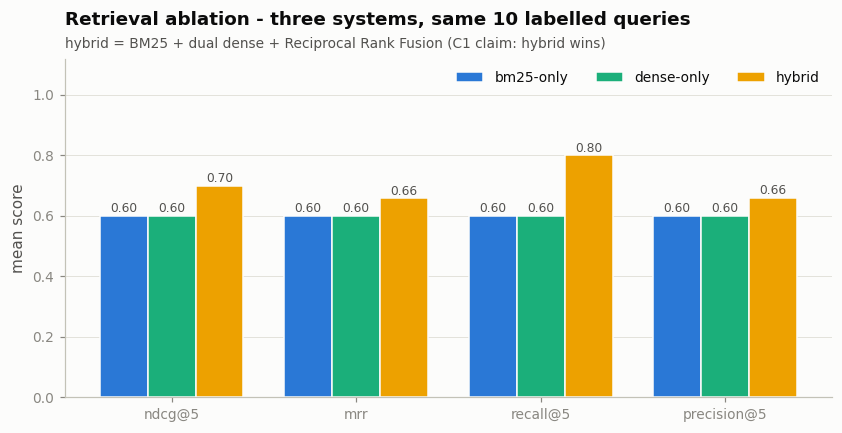

In [8]:
metrics = [c for c in mean_abl.columns]
systems = ["bm25-only", "dense-only", "hybrid"]
x = np.arange(len(metrics)); w = 0.26

fig, ax = plt.subplots(figsize=(9, 4))
for i, s in enumerate(systems):
    vals = [mean_abl.loc[s, m] if s in mean_abl.index else 0 for m in metrics]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=s, color=C[i],
                  edgecolor=INK["surface"], linewidth=1)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}",
                ha="center", fontsize=8, color=INK["secondary"])
ax.set_xticks(x, metrics)
ax.set_ylim(0, 1.12)
ax.legend(title=None, ncols=3)
finish(ax, "Retrieval ablation - three systems, same 10 labelled queries",
       subtitle="hybrid = BM25 + dual dense + Reciprocal Rank Fusion (C1 claim: hybrid wins)",
       ylabel="mean score")
save_fig(fig, "c1_ablation")
plt.show()

figure saved -> reports/figures/05_eval/c1_per_query.png


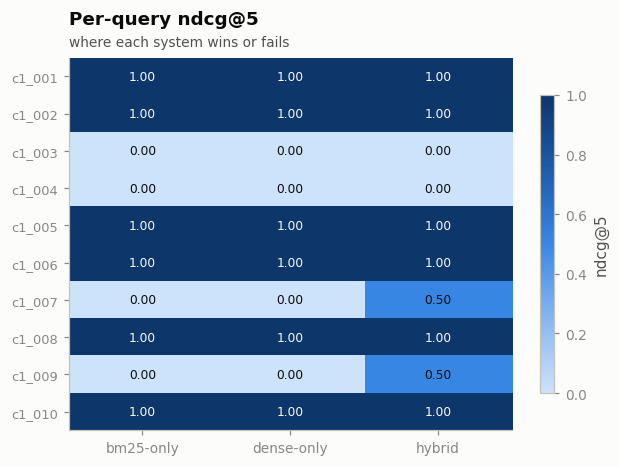

In [9]:
key = next(c for c in abl.columns if c.startswith("ndcg"))
pivot = abl.pivot_table(index="query", columns="system", values=key)

fig, ax = plt.subplots(figsize=(6.5, 4.4))
im = ax.imshow(pivot[systems], cmap=SEQ, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(systems)), systems)
ax.set_yticks(range(len(pivot)), pivot.index, fontsize=8.5)
for i in range(pivot.shape[0]):
    for j, s in enumerate(systems):
        v = pivot[s].iloc[i]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color=INK["surface"] if v > 0.55 else INK["primary"])
fig.colorbar(im, ax=ax, shrink=0.8, label=key)
finish(ax, f"Per-query {key}", subtitle="where each system wins or fails", grid_axis="x")
ax.grid(visible=False)
save_fig(fig, "c1_per_query")
plt.show()

### C1.1 Hyperparameter sensitivity - how deep to retrieve?

`top_k` is the retriever's main free parameter: too small starves the LLM of
context, too large dilutes it. Sweep it and look for the plateau.

In [ ]:
# Retrieval-depth sweep, scored against ground-truth modules.
# NOTE: retrieval_metrics returns per-k keys (ndcg@3, ndcg@5, ...), so we
# normalise them to stable column names - otherwise the groupby yields NaN for
# every k but one and the NDCG line collapses to a single point.
ks = [3, 5, 8, 10]
sweep = []
for k in ks:
    depth = max(k * 4, 20)
    for q in C1_QUERIES:
        relevant = set(q.relevant_modules)
        if not relevant:
            continue
        docs = retriever.retrieve_raw(q.query_text, top_k=depth)
        if not docs:
            continue
        met = retrieval_metrics(modules(docs)[:k], relevant, k=k)
        sweep.append({"k": k,
                      "ndcg": met[f"ndcg@{k}"],
                      "mrr": met["mrr"],
                      "recall": met[f"recall@{k}"],
                      "precision": met[f"precision@{k}"]})
sw = pd.DataFrame(sweep).groupby("k").mean(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(sw.index, sw["ndcg"], marker="o", markersize=8, linewidth=2,
        color=C[0], label="NDCG@k")
ax.plot(sw.index, sw["mrr"], marker="o", markersize=8, linewidth=2,
        color=C[1], label="MRR")
ax.plot(sw.index, sw["recall"], marker="o", markersize=8, linewidth=2,
        color=C[2], label="Recall@k")
ax.set_xticks(ks)
ax.legend()
finish(ax, "Hybrid retrieval vs retrieval depth k",
       subtitle="mean over the labelled C1 bank - pick the smallest k on the plateau",
       xlabel="top_k", ylabel="mean score")
save_fig(fig, "c1_topk_sweep")
plt.show()
sw.round(3)


---
# C2 · Cognitive-bias detection

Official harness numbers first, then per-type Precision/Recall/F1, confusion
matrices, and the raw error listing. The detector emits *decisions* (rule
hits), not probabilities - so decision metrics are the honest ceiling of what
can be reported (no ROC/AUC, see header).

In [11]:
c2 = harness.eval_c2()
print(pd.Series(asdict(c2)).to_string()[:1500])

2026-07-18 22:04:00.698 | INFO     | drona.evaluation.harness:eval_c2:257 - C2 evaluation: bias detection
2026-07-18 22:04:00.701 | INFO     | drona.evaluation.harness:eval_c2:272 - C2: 16 queries - macro P=1.000 R=0.806 F1=0.861


per_bias_metrics    {'availability_heuristic': {'precision': 1.0, ...
macro_avg           {'precision': 1.0, 'recall': 0.805555555555555...
n_queries                                                          16
n_with_bias                                                        13
n_clean                                                             3


In [12]:
from drona.advising.bias_detector import BiasDetector
from drona.evaluation.queries import C2_QUERIES

det = BiasDetector()
preds = []
for q in C2_QUERIES:
    predicted = {str(getattr(f.bias_type, "value", f.bias_type)) for f in det.detect(q.query_text)}
    expected  = {str(getattr(b, "value", b)) for b in q.expected_biases}
    preds.append({"query_id": q.query_id, "text": q.query_text,
                  "expected": expected, "predicted": predicted})

types = sorted({t for p in preds for t in p["expected"] | p["predicted"]})
rows = []
for t in types:
    tp = sum(1 for p in preds if t in p["expected"] and t in p["predicted"])
    fp = sum(1 for p in preds if t not in p["expected"] and t in p["predicted"])
    fn = sum(1 for p in preds if t in p["expected"] and t not in p["predicted"])
    tn = len(preds) - tp - fp - fn
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    rows.append({"bias_type": t, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                 "precision": prec, "recall": rec, "f1": f1})
c2_df = pd.DataFrame(rows).set_index("bias_type")
print(f"macro-F1 = {c2_df['f1'].mean():.3f}")
c2_df.round(3)

macro-F1 = 0.861


,TP,FP,FN,TN,precision,recall,f1
bias_type,,,,,,,
anchoring,2,0,2,12,1.0,0.500,0.667
availability_heuristic,3,0,0,13,1.0,1.000,1.000
confirmation,1,0,2,13,1.0,0.333,0.500
consistency,2,0,0,14,1.0,1.000,1.000
dunning_kruger,2,0,0,14,1.0,1.000,1.000
loss_aversion,2,0,0,14,1.0,1.000,1.000


figure saved -> reports/figures/05_eval/c2_prf.png


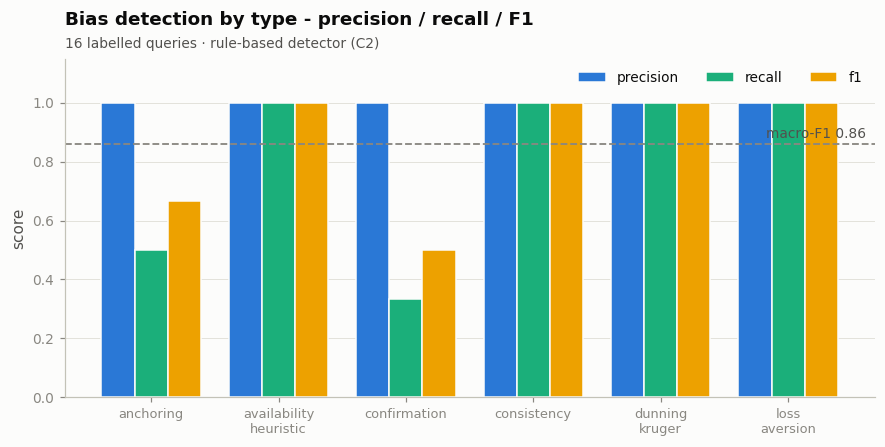

In [13]:
x = np.arange(len(c2_df)); w = 0.26

fig, ax = plt.subplots(figsize=(9.5, 4))
for i, m in enumerate(["precision", "recall", "f1"]):
    bars = ax.bar(x + (i - 1) * w, c2_df[m], w, label=m, color=C[i],
                  edgecolor=INK["surface"], linewidth=1)
ax.set_xticks(x, [t.replace("_", "\n") for t in c2_df.index], fontsize=8.5)
ax.set_ylim(0, 1.15)
ax.axhline(c2_df["f1"].mean(), color=INK["muted"], linestyle="--", linewidth=1.2)
ax.text(0.995, c2_df["f1"].mean() + 0.02, f"macro-F1 {c2_df['f1'].mean():.2f} ",
        ha="right", transform=ax.get_yaxis_transform(), fontsize=9, color=INK["secondary"])
ax.legend(ncols=3)
finish(ax, "Bias detection by type - precision / recall / F1",
       subtitle=f"{len(preds)} labelled queries · rule-based detector (C2)",
       ylabel="score")
save_fig(fig, "c2_prf")
plt.show()

figure saved -> reports/figures/05_eval/c2_confusion.png


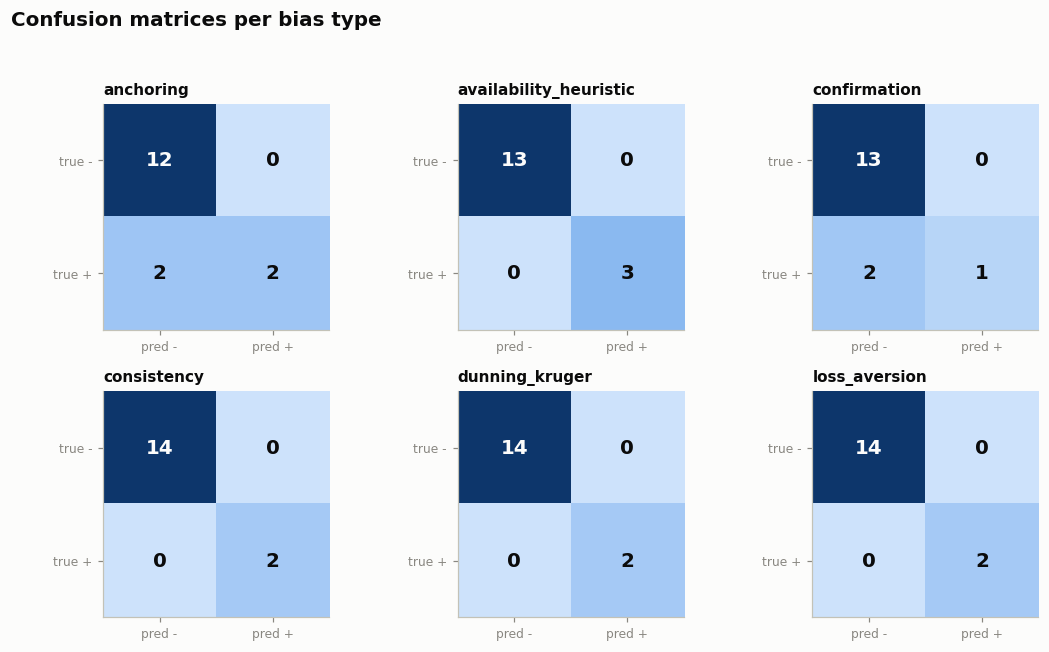

In [14]:
ncol = 3
nrow = int(np.ceil(len(types) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.3 * ncol, 3 * nrow))
for ax, t in zip(np.ravel(axes), types):
    r = c2_df.loc[t]
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]])
    ax.imshow(cm, cmap=SEQ, vmin=0, vmax=max(1, cm.max()))
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=13,
                    fontweight="bold",
                    color=INK["surface"] if cm[i, j] > cm.max() * 0.6 else INK["primary"])
    ax.set_xticks([0, 1], ["pred -", "pred +"], fontsize=8)
    ax.set_yticks([0, 1], ["true -", "true +"], fontsize=8)
    ax.set_title(t, fontsize=10)
    ax.grid(visible=False)
for ax in np.ravel(axes)[len(types):]:
    ax.axis("off")
fig.suptitle("Confusion matrices per bias type", x=0.005, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "c2_confusion")
plt.show()

### C2.1 Error analysis - every miss, verbatim

In [15]:
errors = [{"query": p["query_id"],
           "missed (FN)": ", ".join(sorted(p["expected"] - p["predicted"])) or "-",
           "spurious (FP)": ", ".join(sorted(p["predicted"] - p["expected"])) or "-",
           "text": p["text"][:90]}
          for p in preds if p["expected"] != p["predicted"]]
if errors:
    display(pd.DataFrame(errors))
else:
    print("no detection errors on the labelled query bank")

,query,missed (FN),spurious (FP),text
0,c2_av_001,anchoring,-,"My friend got a job at Leapfrog earning Rs 80,..."
1,c2_av_002,anchoring,-,I heard AI pays really well these days. Should...
2,c2_av_003,confirmation,-,Everyone says cloud computing is the future. W...
3,c2_cf_002,confirmation,-,Don't you agree that data science is the only ...


---
# C3 · Gesture policies: keyframe vs BC vs ACT vs Diffusion

Every policy with an available checkpoint is rolled out on all six gestures in
the same environment. Success requires reaching the gesture apex AND returning
to rest; jerk measures smoothness (lower is better).

In [16]:
import pathlib
from drona.interaction.act_policy import KeyframePolicy, LeRobotACTPolicy
from drona.interaction.bc_policy import BCGesturePolicy, checkpoint_exists
from drona.interaction.diffusion_policy import LeRobotDiffusionPolicy
from drona.interaction.sim_eval import evaluate_policy

def _ckpt_factory(cls, base):
    def f(g):
        for path in (f"{base}/{g}", base):
            try:
                return cls(path)
            except Exception:
                continue
        raise FileNotFoundError(base)
    return f

factories = {"keyframe": lambda g: KeyframePolicy(g)}
if checkpoint_exists("greet"):
    factories["bc"] = lambda g: BCGesturePolicy(g)
if pathlib.Path("data/checkpoints/act").exists():
    factories["act"] = _ckpt_factory(LeRobotACTPolicy, "data/checkpoints/act")
if pathlib.Path("data/checkpoints/diffusion").exists():
    factories["diffusion"] = _ckpt_factory(LeRobotDiffusionPolicy, "data/checkpoints/diffusion")

reports, rows = {}, []
for name, f in factories.items():
    try:
        rep = evaluate_policy(f)
    except Exception as exc:
        print(f"{name}: skipped ({exc})"); continue
    reports[name] = rep
    for g, m in rep.per_gesture.items():
        # the metric dict carries its own policy label - ours must win
        rows.append({**m, "policy": name, "gesture": g})

c3 = pd.DataFrame(rows)
summary = (c3.groupby("policy")
             .agg(success_rate=("success", "mean"), mean_jerk=("jerk", "mean"),
                  mean_path=("path_length", "mean"), mean_apex_err=("apex_error", "mean"))
             .round(4))
print(f"policies evaluated: {list(reports)}")
summary

2026-07-18 22:04:01.840 | INFO     | drona.interaction.sim_eval:evaluate_policy:166 - Sim eval [KeyframePolicy]: success=100%, mean_jerk=0.0005, mean_path=1.197


policies evaluated: ['keyframe']


,success_rate,mean_jerk,mean_path,mean_apex_err
policy,,,,
keyframe,1.0,0.0005,1.1966,0.0832


figure saved -> reports/figures/05_eval/c3_policy_comparison.png


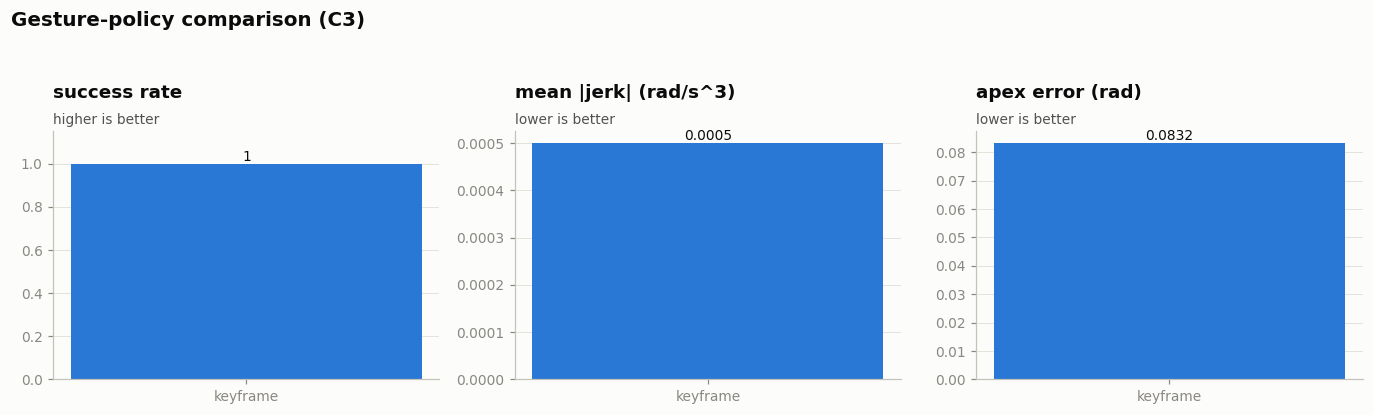

In [17]:
pol_order = [p for p in ["keyframe", "bc", "act", "diffusion"] if p in summary.index]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))

for ax, col, label, better in [
        (axes[0], "success_rate", "success rate", "higher"),
        (axes[1], "mean_jerk", "mean |jerk| (rad/s^3)", "lower"),
        (axes[2], "mean_apex_err", "apex error (rad)", "lower")]:
    vals = summary.loc[pol_order, col]
    bars = ax.bar(pol_order, vals, color=[C[i] for i in range(len(pol_order))], width=0.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3g}",
                ha="center", va="bottom", fontsize=9, color=INK["primary"])
    finish(ax, label, subtitle=f"{better} is better")
    if col == "success_rate":
        ax.set_ylim(0, 1.15)

fig.suptitle("Gesture-policy comparison (C3)", x=0.005, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93))
save_fig(fig, "c3_policy_comparison")
plt.show()

figure saved -> reports/figures/05_eval/c3_jerk_per_gesture.png


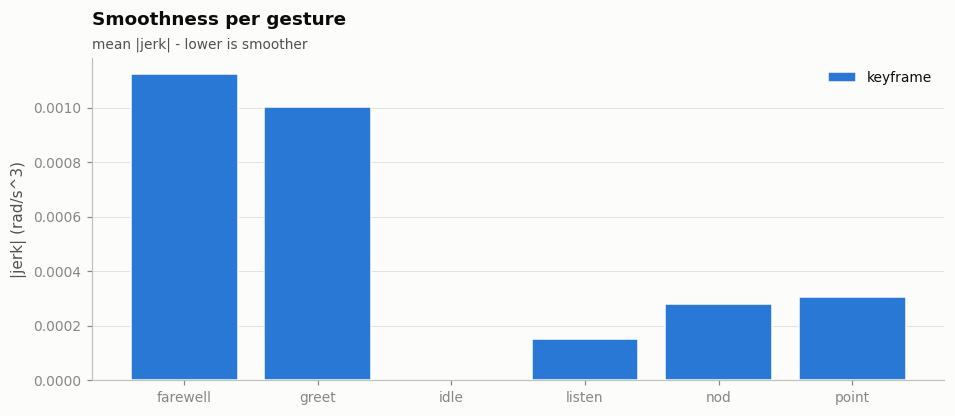

In [18]:
gestures = sorted(c3["gesture"].unique())
x = np.arange(len(gestures)); w = 0.8 / max(1, len(pol_order))

fig, ax = plt.subplots(figsize=(10, 3.8))
for i, p in enumerate(pol_order):
    sub = c3[c3["policy"] == p].set_index("gesture").reindex(gestures)
    ax.bar(x + (i - (len(pol_order) - 1) / 2) * w, sub["jerk"], w,
           label=p, color=C[i], edgecolor=INK["surface"], linewidth=1)
ax.set_xticks(x, gestures)
ax.legend(ncols=len(pol_order))
finish(ax, "Smoothness per gesture", subtitle="mean |jerk| - lower is smoother",
       ylabel="|jerk| (rad/s^3)")
save_fig(fig, "c3_jerk_per_gesture")
plt.show()

### C3.1 Statistics - is the smoothness gain real?

Paired comparison over the six gestures (each gesture is its own control).
n=6 pairs is small - the Wilcoxon p-value is reported honestly alongside the
effect size rather than leaned on.

In [19]:
from drona.evaluation.stats import paired_comparison

base_jerk = c3[c3["policy"] == "keyframe"].set_index("gesture")["jerk"]
for p in pol_order:
    if p == "keyframe":
        continue
    other = c3[c3["policy"] == p].set_index("gesture")["jerk"].reindex(base_jerk.index)
    res = paired_comparison(base_jerk.tolist(), other.tolist(), label=f"keyframe vs {p}")
    print(f"keyframe vs {p}:")
    for k, v in res.items():
        print(f"  {k}: {v}")
    print()

In [20]:
from drona.interaction.sim_eval import rollout
from drona.interaction.mujoco_env import StubEnv

overlay = [p for p in ("act", "bc", "diffusion") if p in factories]
if overlay:
    best = overlay[0]
    fig, axes = plt.subplots(2, 3, figsize=(12.5, 5.6), sharex=True)
    kf_traj = np.array(rollout(factories["keyframe"]("greet"), StubEnv(), 120))
    lp_traj = np.array(rollout(factories[best]("greet"), StubEnv(), 120))
    t = np.arange(len(kf_traj)) * 0.05
    for j, ax in enumerate(np.ravel(axes)):
        ax.plot(t, kf_traj[:, j], color=INK["muted"], linewidth=1.8, label="keyframe")
        ax.plot(t[:len(lp_traj)], lp_traj[:, j], color=C[0], linewidth=1.8, label=best)
        finish(ax, f"joint {j+1}", ylabel="rad" if j % 3 == 0 else None,
               xlabel="time (s)" if j >= 3 else None)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"'greet' trajectory - keyframe vs {best}", x=0.005, ha="left",
                 fontweight="bold", fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    save_fig(fig, "c3_trajectory_overlay")
    plt.show()
else:
    print("no learned checkpoint found - train in notebook 04 first")

no learned checkpoint found - train in notebook 04 first


---
# C4 · Nepal-grounding & latency

Citation-tier ordering with the LLM step disabled (Ollama does not run on
Colab by default). The full latency + generation numbers come from
`python scripts/run_evaluation.py --all --llm` on the local machine, where
Ollama serves the fine-tuned model.

2026-07-18 22:04:03.080 | INFO     | drona.evaluation.harness:eval_c4:373 - C4 evaluation: stack / provenance metrics
2026-07-18 22:04:03.088 | INFO     | drona.advising.retriever:__init__:109 - Retriever ready - curriculum=2348 docs, career=336 docs
2026-07-18 22:04:03.089 | DEBUG    | drona.advising.retriever:retrieve:221 - Retrieving top-20 for query: software jobs Kathmandu Nepal 2024…
2026-07-18 22:04:03.142 | INFO     | drona.advising.retriever:_ensure_bm25:122 - Building BM25 index from curriculum collection…
2026-07-18 22:04:03.468 | INFO     | drona.advising.retriever:_ensure_bm25:134 - BM25 index built over 2348 curriculum documents
2026-07-18 22:04:03.480 | DEBUG    | drona.advising.retriever:retrieve:239 - Retrieved 20 citations (Nepal: 20, Intl: 0)
2026-07-18 22:04:03.480 | DEBUG    | drona.advising.retriever:retrieve:221 - Retrieving top-20 for query: IT companies hiring in Nepal Leapfrog F1Soft Yomari…
2026-07-18 22:04:03.565 | DEBUG    | drona.advising.retriever:retriev

{'nepal_citation_ratio': 1.0, 'target_met': True, 'latency_skipped': True, 'ratio_source': 'retrieval'}
figure saved -> reports/figures/05_eval/c4_citation_ratio.png


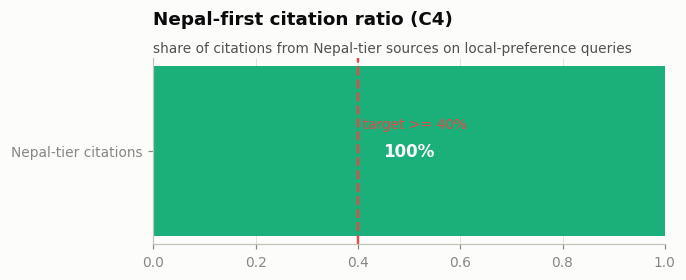

In [21]:
c4 = harness.eval_c4(with_llm=False)
c4d = asdict(c4)
print({k: v for k, v in c4d.items() if not isinstance(v, (list, dict))})

ratio = c4d.get("nepal_citation_ratio", None)
if isinstance(ratio, (int, float)):
    fig, ax = plt.subplots(figsize=(6, 2.2))
    ax.barh(["Nepal-tier citations"], [ratio], color=C[1], height=0.45)
    ax.barh(["Nepal-tier citations"], [1 - ratio], left=[ratio], color=INK["grid"], height=0.45)
    ax.axvline(0.4, color=C[5], linewidth=1.6, linestyle="--")
    ax.text(0.4, 0.62, " target >= 40%", fontsize=9, color=C[5], transform=ax.get_xaxis_transform())
    ax.text(ratio / 2, 0, f"{ratio:.0%}", ha="center", va="center",
            fontsize=11, fontweight="bold", color=INK["surface"])
    ax.set_xlim(0, 1)
    finish(ax, "Nepal-first citation ratio (C4)",
           subtitle="share of citations from Nepal-tier sources on local-preference queries",
           grid_axis="x")
    save_fig(fig, "c4_citation_ratio")
    plt.show()

---
# LLM · base vs fine-tuned (from notebook 04)

Notebook 04 recorded the base model's validation loss before training and the
curve during training - the comparison is therefore free here, no GPU needed.

In [ ]:
import json, pathlib

sft_path = pathlib.Path("reports/sft_metrics.json")
if sft_path.exists():
    sft = json.loads(sft_path.read_text())
    base_l, final_l = sft["base_eval_loss"], sft["final_eval_loss"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    ev = [(h["step"], h["eval_loss"]) for h in sft["log_history"] if "eval_loss" in h]
    if ev:
        axes[0].plot(*zip(*ev), marker="o", markersize=7, linewidth=2, color=C[0])
    axes[0].axhline(base_l, color=INK["muted"], linestyle="--", linewidth=1.4)
    axes[0].text(0.99, base_l, " base", ha="right", va="bottom", fontsize=9,
                 color=INK["secondary"], transform=axes[0].get_yaxis_transform())
    finish(axes[0], "Validation loss across training", xlabel="step", ylabel="CE loss")

    bars = axes[1].bar(["base\nQwen3-4B", "fine-tuned\n(+LoRA)"],
                       [base_l, final_l], color=[INK["muted"], C[0]], width=0.5)
    for b, v in zip(bars, [base_l, final_l]):
        axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center",
                     va="bottom", fontsize=10, fontweight="bold")
    delta = 100 * (base_l - final_l) / base_l
    finish(axes[1], f"Final comparison - {delta:.0f}% lower val loss",
           ylabel="CE loss")
    fig.tight_layout()
    save_fig(fig, "llm_base_vs_lora")
    plt.show()
else:
    print("reports/sft_metrics.json not found - run notebook 04 (Part A) first.")
    print("Generation-quality ablation runs locally: scripts/run_evaluation.py --llm")

---
# Final comparison & verdict

One table across every system, saved for the thesis. "Winner" per row states
the model this evaluation selects and the evidence column says why.

In [ ]:
import json, datetime, pathlib

verdict_rows = []

# C1 - retrieval system
best_ret = mean_abl[key].idxmax() if key in mean_abl else "hybrid"
verdict_rows.append({
    "component": "retrieval (C1)",
    "candidates": ", ".join(mean_abl.index),
    "winner": best_ret,
    "evidence": f"{key}: " + ", ".join(f"{s}={mean_abl.loc[s, key]:.2f}" for s in mean_abl.index),
})

# C2 - bias detector (no competitor - report absolute quality)
verdict_rows.append({
    "component": "bias detection (C2)",
    "candidates": "rule-based detector",
    "winner": "rule-based detector",
    "evidence": f"macro-F1={c2_df['f1'].mean():.2f} over {len(types)} bias types",
})

# C3 - gesture policy
if len(summary) > 1:
    cand = summary.drop(index="keyframe", errors="ignore")
    ok = cand[cand["success_rate"] >= summary.loc["keyframe", "success_rate"]]
    pool = ok if len(ok) else cand
    best_pol = pool["mean_jerk"].idxmin()
    ev = (f"jerk {summary.loc[best_pol,'mean_jerk']:.4f} vs keyframe "
          f"{summary.loc['keyframe','mean_jerk']:.4f}, success "
          f"{summary.loc[best_pol,'success_rate']:.0%}")
else:
    best_pol, ev = "keyframe", "no learned checkpoints present - run notebook 04"
verdict_rows.append({"component": "gesture policy (C3)",
                     "candidates": ", ".join(summary.index),
                     "winner": best_pol, "evidence": ev})

# LLM
if sft_path.exists():
    verdict_rows.append({
        "component": "advising LLM",
        "candidates": "base Qwen3-4B-Instruct-2507, +LoRA",
        "winner": "+LoRA" if final_l < base_l else "base",
        "evidence": f"val CE {final_l:.3f} vs base {base_l:.3f}",
    })

verdict = pd.DataFrame(verdict_rows)
pathlib.Path("reports").mkdir(exist_ok=True)
verdict.to_csv("reports/final_comparison.csv", index=False)

report = {
    "generated": datetime.datetime.now().isoformat(timespec="seconds"),
    "c1_official": {"hybrid": c1.hybrid_metrics, "dense_only": c1.dense_only_metrics},
    "c1_ablation": mean_abl.to_dict(),
    "c2_per_type": c2_df.to_dict(orient="index"),
    "c2_macro_f1": float(c2_df["f1"].mean()),
    "c3_summary": summary.to_dict(orient="index"),
    "c4": {k: v for k, v in c4d.items() if isinstance(v, (int, float, str, bool))},
    "verdict": verdict_rows,
}
pathlib.Path("reports/evaluation_report.json").write_text(json.dumps(report, indent=2, default=str))
print("saved -> reports/final_comparison.csv, reports/evaluation_report.json\n")
verdict

## How these numbers map to the thesis claims

- **C1** - the ablation table + per-query heatmap are the direct evidence that
  *hybrid retrieval outperforms dense-only and BM25-only* on this knowledge base.
- **C2** - per-type P/R/F1 + confusion matrices quantify the bias detector;
  the error listing is the discussion material for its failure modes.
- **C3** - the policy comparison + paired statistics support *learned gestures
  are smoother than the keyframe baseline*, with success rate guarding validity.
- **C4** - the citation-ratio gauge shows Nepal-tier grounding against the
  >= 40% target; run the local `--llm` evaluation for latency and generation quality.

Figures for all of the above are in `reports/figures/05_eval/` at 200 dpi,
ready for the report.